=== Distance Matrix (Euclidean) ===
          a         b         c         d         e         f
a  0.000000  0.707107  5.656854  3.605551  4.242641  3.201562
b  0.707107  0.000000  4.949747  2.915476  3.535534  2.500000
c  5.656854  4.949747  0.000000  2.236068  1.414214  2.500000
d  3.605551  2.915476  2.236068  0.000000  1.000000  0.500000
e  4.242641  3.535534  1.414214  1.000000  0.000000  1.118034
f  3.201562  2.500000  2.500000  0.500000  1.118034  0.000000


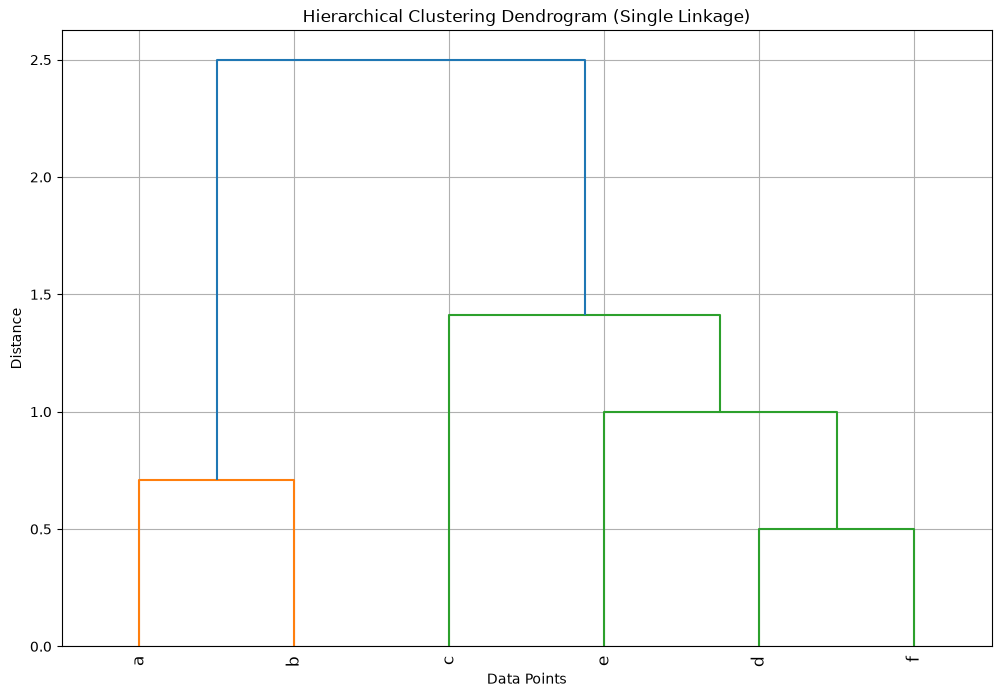

In [1]:
import numpy as np
import pandas as pd
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import pdist, squareform
import matplotlib.pyplot as plt
 
# 1. dataset sederhana
data = np.array([
    [1.0, 1.0],  # a
    [1.5, 1.5],  # b
    [5.0, 5.0],  # c
    [3.0, 4.0],  # d
    [4.0, 4.0],  # e
    [3.0, 3.5]   # f
])

# 2. hitung Distance Matrix (Euclidean Distance)
distance_matrix = pdist(data, metric='euclidean')
distance_df = pd.DataFrame(squareform(distance_matrix),
                            columns=['a', 'b', 'c', 'd', 'e', 'f'],
                            index=['a', 'b', 'c', 'd', 'e', 'f'])
 
# 3. tampilkan distance matrix
print("=== Distance Matrix (Euclidean) ===")
print(distance_df)
 
# 4. hierarchical clustering (single linkage)
linked = linkage(data, method='single')
 
# 5. plot Dendrogram
plt.figure(figsize=(12, 8))
plt.title("Hierarchical Clustering Dendrogram (Single Linkage)")
dendrogram(linked, labels=['a', 'b', 'c', 'd', 'e', 'f'], leaf_rotation=90)
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.grid(True)
plt.show()

- numpy dan pandas digunakan untuk mengelola data dan matriks
- linkage, dendrogram dari scipy.cluster.hierarchy digunakan untuk proses hierarchical clustering dan visualisasinya
- pdist, squareform dari scipy.spatial.distance digunakan untuk menghitung jarak antar titik
- Dataset sederhana dibuat berisi 6 titik (a–f) dengan 2 fitur (koordinat x dan y)
- pdist(data, metric='euclidean') menghitung jarak Euclidean antar semua pasangan titik, lalu squareform mengubahnya menjadi bentuk matriks (distance matrix) agar mudah dibaca
- linkage(data, method='single') melakukan hierarchical clustering dengan Single Linkage, yaitu jarak antar klaster dihitung dari pasangan titik terdekat di antara kedua klaster
- dendrogram() menampilkan hasil clustering dalam bentuk pohon (dendrogram), di mana sumbu y menunjukkan jarak saat dua klaster digabungkan

In [3]:
import pandas as pd
df = pd.read_csv("Mall_Customers.csv")
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


- Dataset Mall_Customers.csv dibaca ke dalam DataFrame df
- head() menampilkan 5 baris pertama untuk memastikan data terbaca dengan benar

In [4]:
x = df.iloc[:, [3, 4]].values

x = df.iloc[:, [3, 4]].values mengambil kolom Annual Income dan Spending Score sebagai fitur yang akan dipakai untuk clustering

In [5]:
from sklearn.preprocessing import StandardScaler
 
data_scaler = StandardScaler()
 
scaled_data = data_scaler.fit_transform(x)
scaled_data.shape

(200, 2)

- StandardScaler() menstandarkan skala kedua fitur agar memiliki rata-rata 0 dan standar deviasi 1
- Scaling ini penting karena hierarchical clustering menghitung jarak antar titik, sehingga fitur dengan rentang nilai besar (seperti Annual Income) tidak boleh mendominasi fitur dengan rentang nilai kecil
- scaled_data.shape menghasilkan (200, 2), menandakan ada 200 data pelanggan dengan 2 fitur

In [6]:
from scipy.cluster.hierarchy import linkage, dendrogram
 
clustering = linkage(scaled_data, method="complete", metric="euclidean")

linkage(scaled_data, method="complete", metric="euclidean") melakukan hierarchical clustering dengan Complete Linkage, yaitu jarak antar klaster dihitung dari pasangan titik terjauh di antara kedua klaster

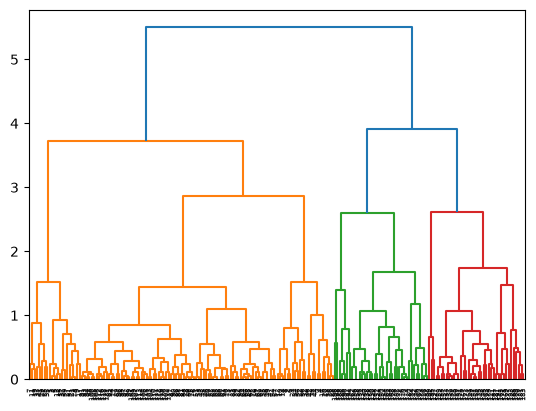

In [7]:
import matplotlib.pyplot as plt
 
dendrogram(clustering)
plt.show()

- dendrogram(clustering) menampilkan hasil clustering dalam bentuk dendrogram
- Dendrogram ini membagi data pelanggan menjadi tiga kelompok utama (oranye, hijau, merah), yang bisa dimanfaatkan untuk segmentasi pelanggan berdasarkan pola pengeluaran, misalnya kelompok pengeluaran rendah, sedang, dan tinggi

# Tugas

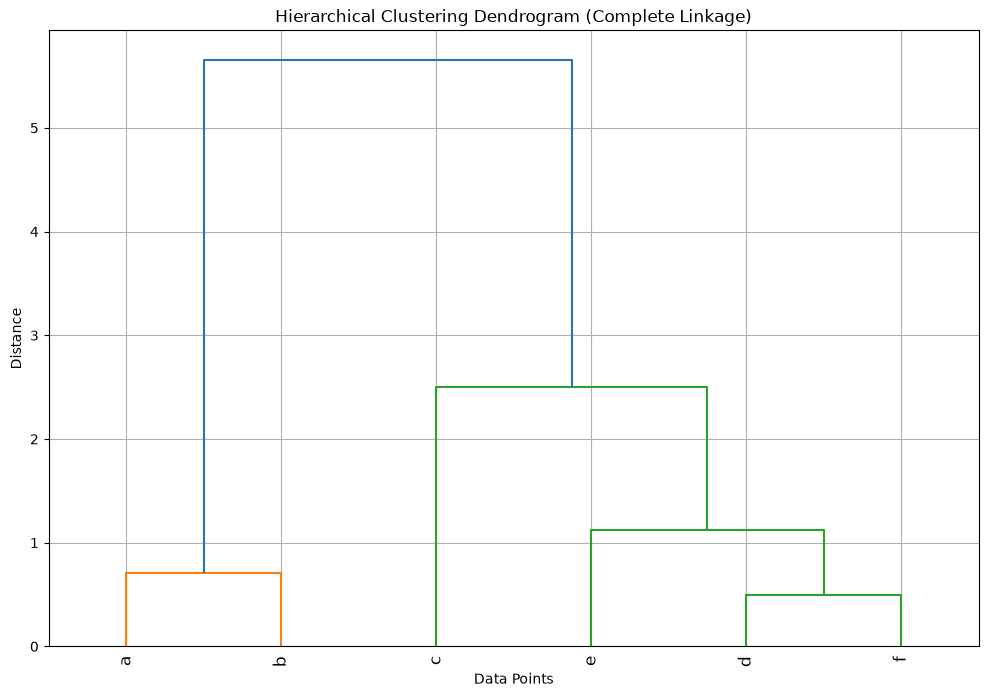

In [8]:
#complete linkage
linked_complete = linkage(data, method='complete')
 
plt.figure(figsize=(12, 8))
plt.title("Hierarchical Clustering Dendrogram (Complete Linkage)")
dendrogram(linked_complete, labels=['a', 'b', 'c', 'd', 'e', 'f'], leaf_rotation=90)
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.grid(True)
plt.show()

linkage(data, method='complete') mengulang proses clustering pada dataset sederhana (a–f), tapi dengan kriteria Complete Linkage

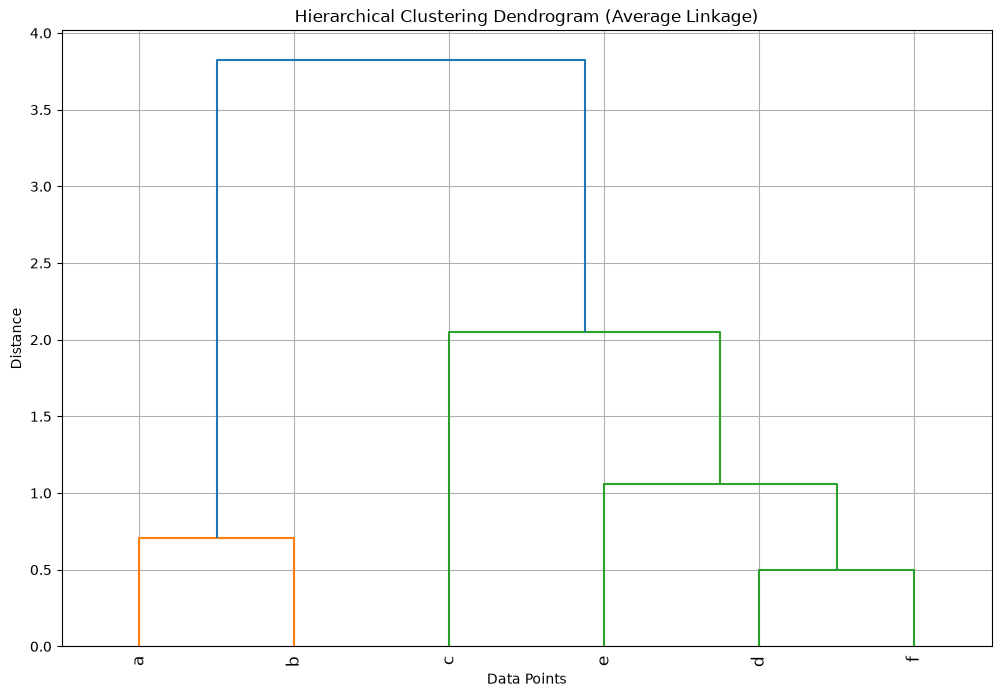

In [9]:
#average linkage
linked_average = linkage(data, method='average')
 
plt.figure(figsize=(12, 8))
plt.title("Hierarchical Clustering Dendrogram (Average Linkage)")
dendrogram(linked_average, labels=['a', 'b', 'c', 'd', 'e', 'f'], leaf_rotation=90)
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.grid(True)
plt.show()

linkage(data, method='average') mengulang proses yang sama dengan kriteria Average Linkage, yaitu jarak antar klaster dihitung dari rata-rata jarak seluruh pasangan titik di antara kedua klaster

# Hasil Analisis
- Single Linkage menghasilkan jarak penggabungan terkecil karena hanya mempertimbangkan jarak antara titik terdekat antar klaster, yaitu jarak dari titik b ke titik terdekat di klaster lainnya. Dendrogramnya terlihat lebih rapat di bagian atas, dan metode ini rentan terhadap efek chaining, di mana klaster bisa memanjang mengikuti titik-titik yang berdekatan secara berantai, meskipun titik-titik di ujungnya sebenarnya jauh.
- Complete Linkage menghasilkan jarak penggabungan yang paling besar karena memperhitungkan jarak terjauh antar klaster, yaitu jarak dari titik a ke titik c yang mencapai 5.66, yang merupakan jarak terjauh di seluruh dataset. Dendrogramnya terlihat lebih renggang di bagian atas, dan metode ini biasanya menghasilkan klaster yang lebih padat dan berbentuk bulat atau seimbang, karena menghindari pembentukan klaster yang terlalu panjang.
- Metode Average Linkage berada di tengah-tengah kedua metode tersebut, karena memperhitungkan rata-rata jarak semua titik antara dua klaster, sehingga hasilnya memberikan keseimbangan yang lebih baik antara kepekaan terhadap data ekstrem (seperti Complete) dan risiko menggabungkan klaster yang tidak seharusnya (seperti Single).